In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, Normalize
import numpy as np
import polars as pl

from cx.plotting import plot_weights, plot_grouped_weights

In [11]:
W_fly_sample = np.load("data/fly-sample-full.npy")
W_bee_sample = np.load("data/bee-sample-full.npy")
W_fly_mean = np.load("data/fly-extrapolated-full.npy")
#W_bee_mean = np.load("data/connectomes/final/bee-grafted-full.npy")
W_fly = np.load("data/fly-grafted-full.npy")
W_bee = np.load("data/bee-grafted-full.npy")
W_fly_truth = np.load("data/fly-truth-full.npy")
fly_cells = pl.read_csv("data/input/fly-cells.csv")
bee_cells = pl.read_parquet("data/input/bee-cells.parquet")

FLY_STD = 0.3902302444625201

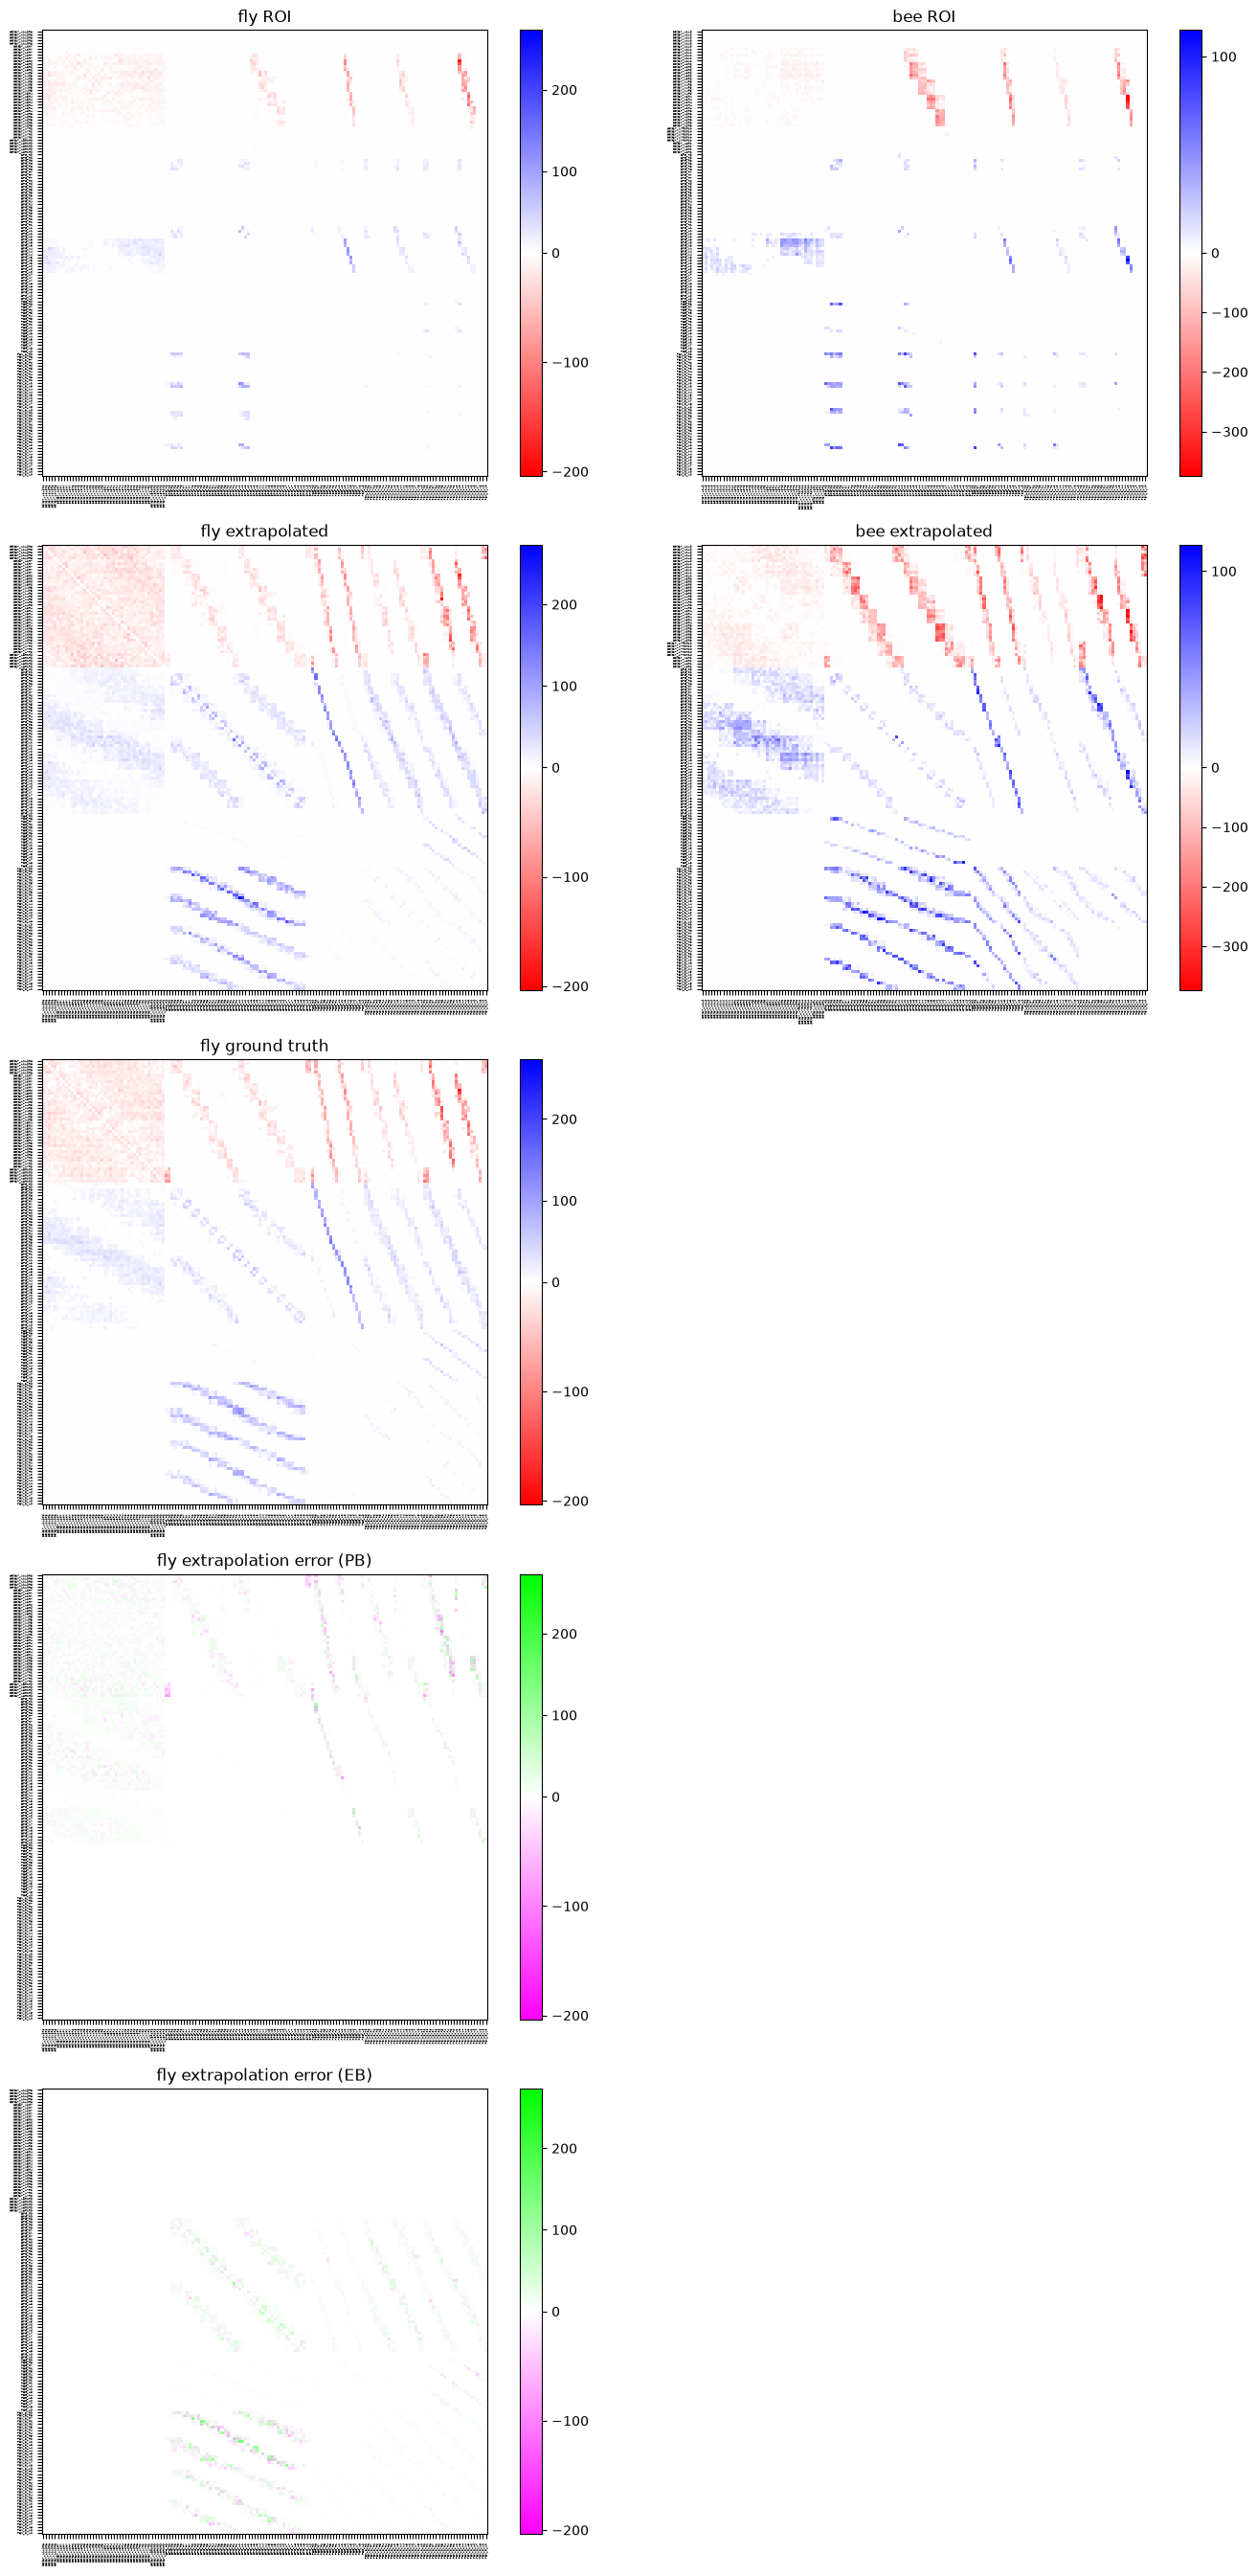

In [21]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10)) = plt.subplots(5, 2, figsize=(14, 27))

fly_norm = TwoSlopeNorm(0.0)
bee_norm = TwoSlopeNorm(0.0)

ax1.set_title("fly ROI")
ax1.set_aspect("equal")
c = plot_weights(np.sum(W_fly_sample, axis=0), labels=fly_cells["type"] + "_" + fly_cells["subtype"], ax=ax1, cmap="bwr_r", norm=fly_norm)
fly_norm.vmin = np.minimum(fly_norm.vmin, W_fly_sample.sum(0).min())
fly_norm.vmax = np.maximum(fly_norm.vmax, W_fly_sample.sum(0).max())
#plt.colorbar(c)

ax3.set_title("fly extrapolated")
ax3.set_aspect("equal")
c = plot_weights(np.sum(W_fly, axis=0), labels=fly_cells["type"] + "_" + fly_cells["subtype"], ax=ax3, cmap="bwr_r", norm=fly_norm)
fly_norm.vmin = np.minimum(fly_norm.vmin, W_fly.sum(0).min())
fly_norm.vmax = np.maximum(fly_norm.vmax, W_fly.sum(0).max())
#plt.colorbar(c)

ax5.set_title("fly ground truth")
ax5.set_aspect("equal")
c = plot_weights(np.sum(W_fly_truth, axis=0), labels=fly_cells["type"] + "_" + fly_cells["subtype"], ax=ax5, cmap="bwr_r", norm=fly_norm)
fly_norm.vmin = np.minimum(fly_norm.vmin, W_fly_truth.sum(0).min())
fly_norm.vmax = np.maximum(fly_norm.vmax, W_fly_truth.sum(0).max())
#plt.colorbar(c)

# Old (difference between extrapolated and true is less than two std deviations):
E = np.abs(W_fly) - np.abs(W_fly_truth)
E_std = np.abs(W_fly_mean) * 2 * FLY_STD
E_inside_std = E.copy()
E_inside_std[np.abs(E) >= E_std] = np.nan
E_outside_std = E.copy()
E_outside_std[np.abs(E) < E_std] = np.nan

# New: both extrapolated (with noise)?
# E = np.abs(W_fly) - np.abs(W_fly_truth)
# E_std = np.abs(W_fly_mean) * 2 * FLY_STD
# E_inside_std = E.copy()
# E_inside_std[np.abs(E) >= E_std] = np.nan
# E_outside_std = E.copy()
# E_outside_std[np.abs(E) < E_std] = np.nan

cmap = LinearSegmentedColormap.from_list(
    "errors",
    [
        (0.0, "magenta"),
        (0.5, "white"),
        (1.0, "lime"),
    ]
)

ax7.set_title("fly extrapolation error (PB)")
ax7.set_aspect("equal")
c = plot_weights(E_outside_std[0,:,:], labels=fly_cells["type"] + "_" + fly_cells["subtype"], ax=ax7, cmap=cmap, norm=fly_norm)
ax7.imshow(np.abs(E_inside_std[0,:,:]), interpolation="nearest", cmap="binary", alpha=0.2, vmin=0)
#plt.colorbar(c)

ax9.set_title("fly extrapolation error (EB)")
ax9.set_aspect("equal")
c = plot_weights(E_outside_std[1,:,:], labels=fly_cells["type"] + "_" + fly_cells["subtype"], ax=ax9, cmap=cmap, norm=fly_norm)
ax9.imshow(np.abs(E_inside_std[1,:,:]), interpolation="nearest", cmap="binary", alpha=0.2, vmin=0)
#plt.colorbar(c)

ax2.set_title("bee ROI")
ax2.set_aspect("equal")
c = plot_weights(np.sum(W_bee_sample, axis=0), labels=bee_cells["type"] + "_" + bee_cells["subtype"], ax=ax2, cmap="bwr_r", norm=bee_norm)
bee_norm.vmin = np.minimum(bee_norm.vmin, W_bee_sample.sum(0).min())
bee_norm.vmax = np.maximum(bee_norm.vmax, W_bee_sample.sum(0).max())
#plt.colorbar(c)

ax4.set_title("bee extrapolated")
ax4.set_aspect("equal")
c = plot_weights(np.sum(W_bee, axis=0), labels=bee_cells["type"] + "_" + bee_cells["subtype"], ax=ax4, cmap="bwr_r", norm=bee_norm)
bee_norm.vmin = np.minimum(bee_norm.vmin, W_bee.sum(0).min())
bee_norm.vmax = np.maximum(bee_norm.vmax, W_bee.sum(0).max())
#plt.colorbar(c)

fig.delaxes(ax6)
fig.delaxes(ax8)
fig.delaxes(ax10)

#fly_norm.vmin = np.minimum(fly_norm.vmin, -fly_norm.vmax)
#bee_norm.vmin = np.minimum(bee_norm.vmin, -bee_norm.vmax)
#fly_norm.vmax = np.maximum(-fly_norm.vmin, fly_norm.vmax)
#bee_norm.vmax = np.maximum(-bee_norm.vmin, bee_norm.vmax)

plt.tight_layout()
plt.savefig("results/extrapolation.pdf")
plt.show()


In [ ]:
W_fly_sample_grouped = np.load("../results/data/fly-mean-conn.npy")
W_bee_sample_grouped = np.load("../results/data/bee-mean-conn.npy")
W_fly_truth_grouped = np.load("../data/connectome/fly-truth.npy")
W_fly_extrapolated_grouped = np.load("../data/connectomes/final/fly-extrapolated-grafted-grouped.npy")
W_bee_extrapolated_grouped = np.load("../data/connectomes/final/bee-extrapolated-grafted-grouped.npy")

fly_cells_grouped = pl.read_csv("../data/connectomes/final/fly-cells.csv")
bee_cells_grouped = pl.read_csv("../data/connectomes/final/bee-cells.csv")

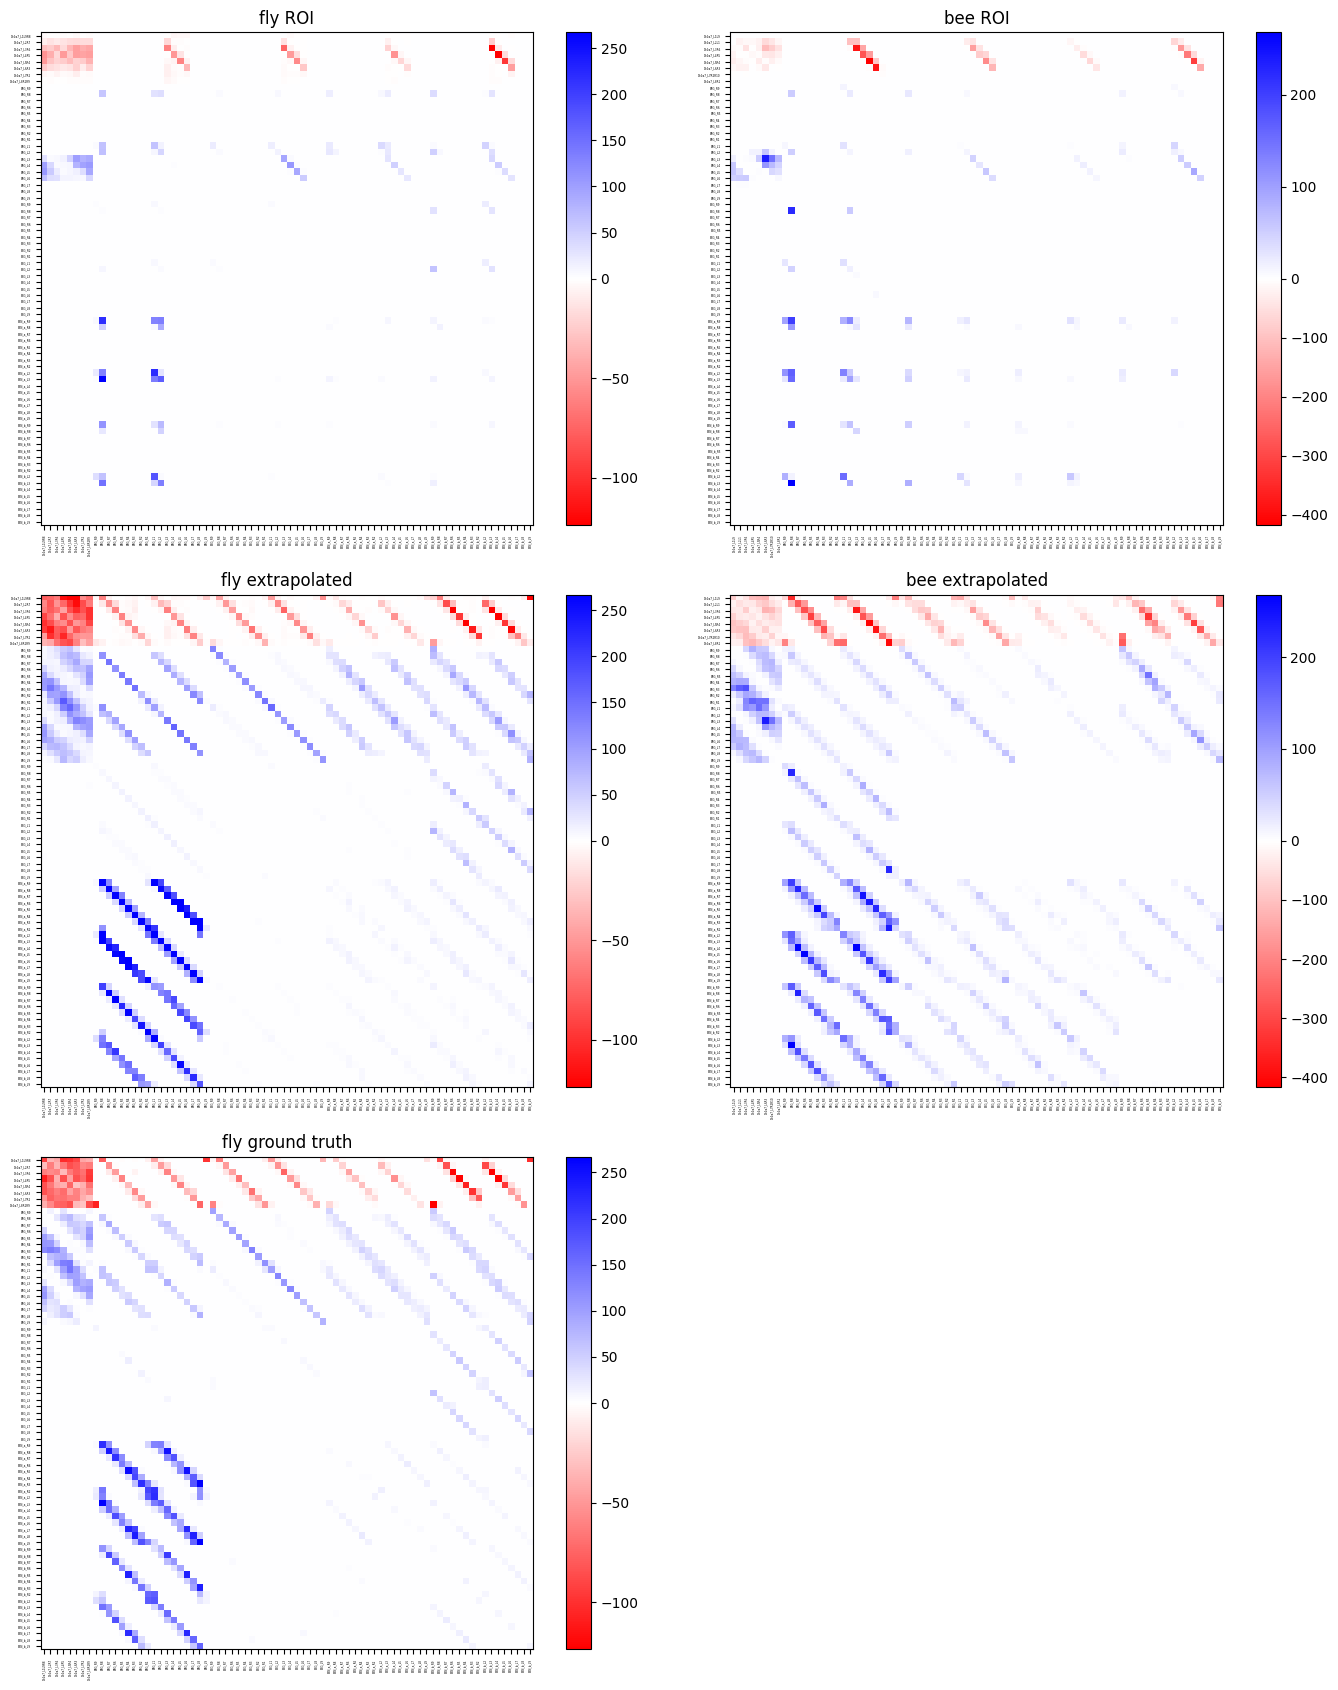

In [ ]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14, 17))

fly_norm = TwoSlopeNorm(0.0)
bee_norm = TwoSlopeNorm(0.0)

ax1.set_title("fly ROI")
ax1.set_aspect("equal")
c = plot_weights(np.sum(W_fly_sample_grouped, axis=0), labels=fly_cells_grouped["type"] + "_" + fly_cells_grouped["subtype"], ax=ax1, cmap="bwr_r", norm=fly_norm)

ax3.set_title("fly extrapolated")
ax3.set_aspect("equal")
c = plot_weights(np.sum(W_fly_extrapolated_grouped, axis=0), labels=fly_cells_grouped["type"] + "_" + fly_cells_grouped["subtype"], ax=ax3, cmap="bwr_r", norm=fly_norm)

ax5.set_title("fly ground truth")
ax5.set_aspect("equal")
c = plot_weights(np.sum(W_fly_truth_grouped, axis=0), labels=fly_cells_grouped["type"] + "_" + fly_cells_grouped["subtype"], ax=ax5, cmap="bwr_r", norm=fly_norm)

# Old (difference between extrapolated and true is less than two std deviations):
#E = np.abs(W_fly) - np.abs(W_fly_truth)
#E_std = np.abs(W_fly_mean) * 2 * FLY_STD
#E_inside_std = E.copy()
#E_inside_std[np.abs(E) >= E_std] = np.nan
#E_outside_std = E.copy()
#E_outside_std[np.abs(E) < E_std] = np.nan

cmap = LinearSegmentedColormap.from_list(
    "errors",
    [
        (0.0, "magenta"),
        (0.5, "white"),
        (1.0, "lime"),
    ]
)

ax2.set_title("bee ROI")
ax2.set_aspect("equal")
c = plot_weights(np.sum(W_bee_sample_grouped, axis=0), labels=bee_cells_grouped["type"] + "_" + bee_cells_grouped["subtype"], ax=ax2, cmap="bwr_r", norm=bee_norm)

ax4.set_title("bee extrapolated")
ax4.set_aspect("equal")
c = plot_weights(np.sum(W_bee_extrapolated_grouped, axis=0), labels=bee_cells_grouped["type"] + "_" + bee_cells_grouped["subtype"], ax=ax4, cmap="bwr_r", norm=bee_norm)

fig.delaxes(ax6)

#fly_norm.vmin = np.minimum(fly_norm.vmin, -fly_norm.vmax)
#bee_norm.vmin = np.minimum(bee_norm.vmin, -bee_norm.vmax)
#fly_norm.vmax = np.maximum(-fly_norm.vmin, fly_norm.vmax)
#bee_norm.vmax = np.maximum(-bee_norm.vmin, bee_norm.vmax)

plt.tight_layout()
plt.savefig("../results/extrapolation-grouped.pdf")
plt.show()


In [ ]:
common_cells = pl.read_csv("../data/connectome/common-cells.csv")
common_cells.show()

index,type,subtype
i64,str,str
0,"""Delta7""","""L1L9R8"""
1,"""Delta7""","""L2R7"""
2,"""Delta7""","""L3R6"""
3,"""Delta7""","""L4R5"""
4,"""Delta7""","""L5R4"""


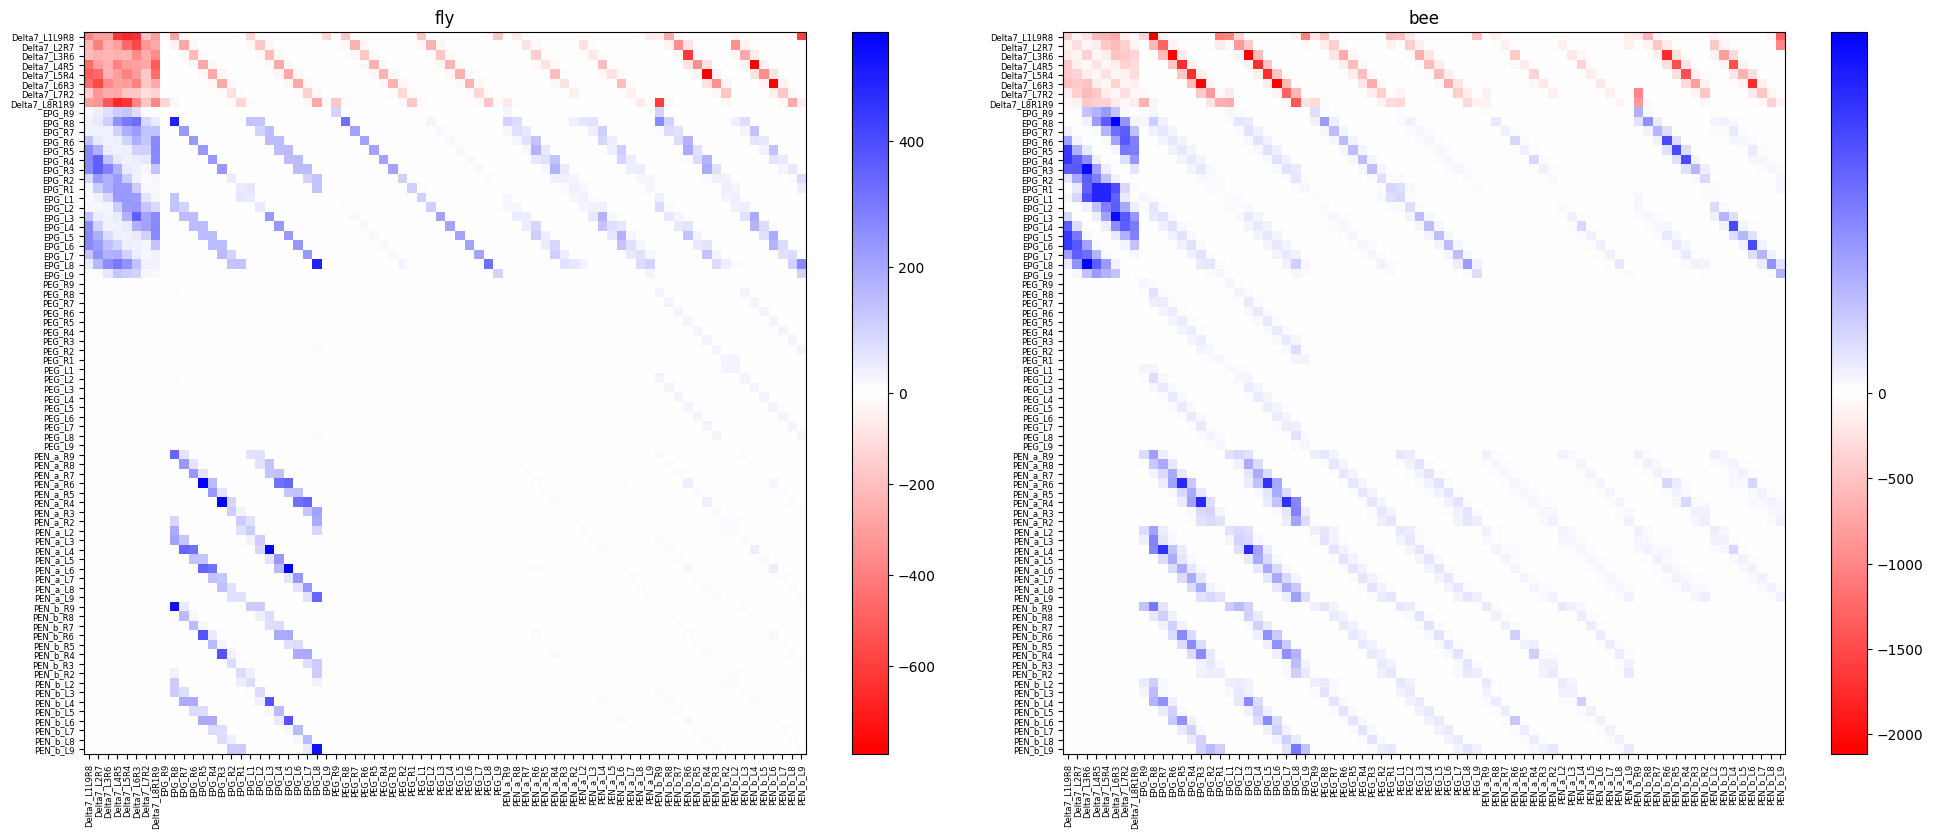

In [ ]:

W_fly_grouped = np.load("../data/connectome/fly-mean-conn.npy")
W_bee_grouped = np.load("../data/connectome/bee-mean-conn.npy")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
ax1.set_title("fly")
ax2.set_title("bee")
c = plot_grouped_weights(W_fly_grouped.sum(axis=0), common_cells["type"] + "_" + common_cells["subtype"], ax=ax1, norm=TwoSlopeNorm(0), cmap="bwr_r")
plt.colorbar(c)
c = plot_grouped_weights(W_bee_grouped.sum(axis=0), common_cells["type"] + "_" + common_cells["subtype"], ax=ax2, norm=TwoSlopeNorm(0), cmap="bwr_r")
plt.colorbar(c)
plt.tight_layout()
plt.savefig("../results/grouped-sum.pdf")
plt.show()

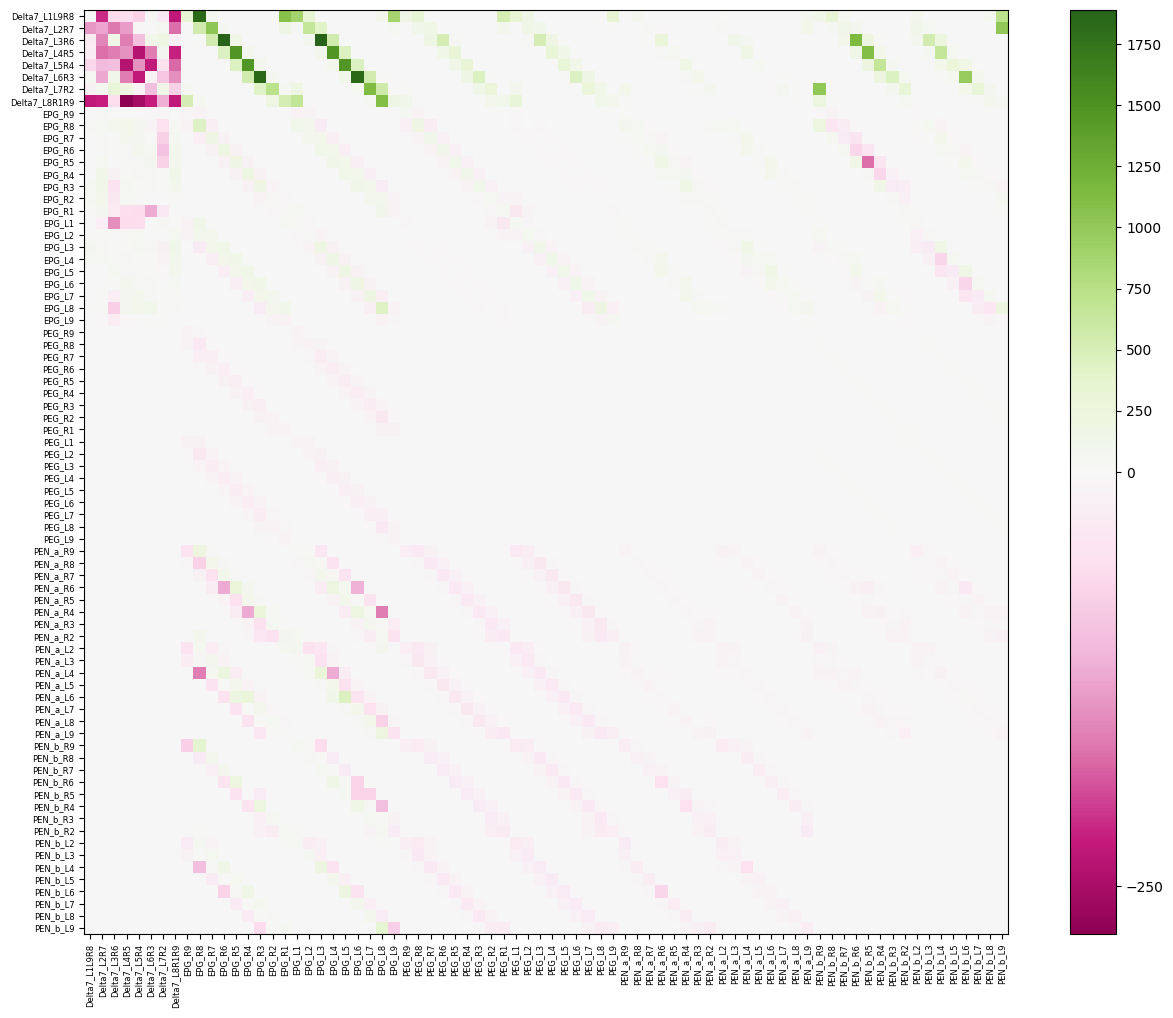

In [20]:
fig = plt.figure(figsize=(16, 12))
ax = plt.gca()
c = plot_grouped_weights(W_fly_grouped.sum(axis=0) - W_bee_grouped.sum(axis=0), common_cells["type"] + "_" + common_cells["subtype"], ax=ax, norm=TwoSlopeNorm(0), cmap="PiYG")
plt.colorbar(c)
plt.savefig("../results/difference-sum.pdf")
plt.show()